<a href="https://colab.research.google.com/github/rosymrd/2025_Pengolahan-Citra_TI2A/blob/main/Jobsheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak Euclidean (Patch1 vs Patch2): 24.7650
Jarak Euclidean (Patch1 vs Patch3): 5.0000
Jarak Manhattan (Patch1 vs Patch2): 936.4392
Jarak Manhattan (Patch1 vs Patch3): 250.0000


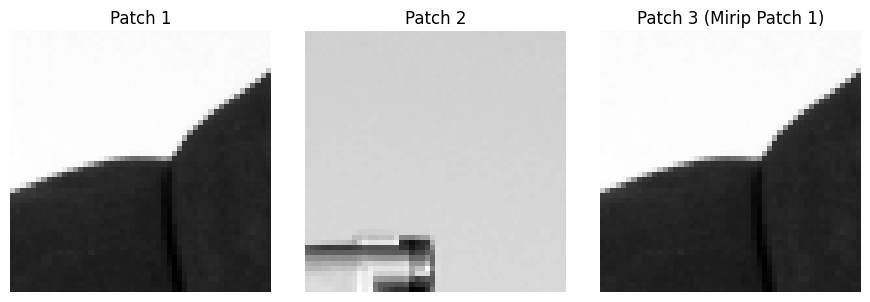

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil citra grayscale dan buat tiga patch
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = np.clip(patch1 + 0.1, 0, 1)  # Patch1 + noise, lalu diklip

# 2. Flatten patch jadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil jarak
print(f"Jarak Euclidean (Patch1 vs Patch2): {dist_l2_12:.4f}")
print(f"Jarak Euclidean (Patch1 vs Patch3): {dist_l2_13:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch2): {dist_l1_12:.4f}")
print(f"Jarak Manhattan (Patch1 vs Patch3): {dist_l1_13:.4f}")

# 6. Visualisasi ketiga patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
titles = ['Patch 1', 'Patch 2', 'Patch 3 (Mirip Patch 1)']
patches = [patch1, patch2, patch3]

for ax, patch, title in zip(axes, patches, titles):
    ax.imshow(patch, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


Cosine Similarity antara Image 1 dan Image 2: 0.8156
Cosine Similarity antara Image 1 dan Image 3 (same): 1.0000
Cosine Similarity antara Image 1 dan Image 4 (downsampled): 1.0000


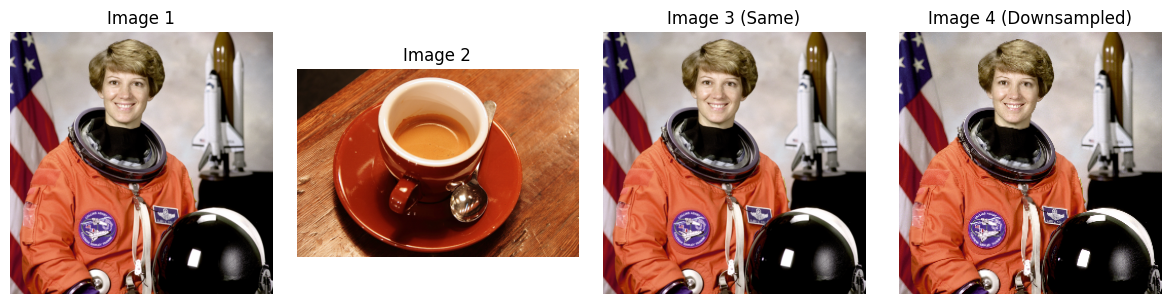

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram gabungan dari kanal RGB
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan ketiganya dan normalisasi
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_combined /= np.sum(hist_combined)

    return hist_combined

# 1. Muat beberapa citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()  # Duplikat image1
    image4 = image1[::2, ::2, :]  # Downsampled image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram RGB gabungan
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - cosine distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 dan Image 2: {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 dan Image 3 (same): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 dan Image 4 (downsampled): {sim_14:.4f}")

# 5. Visualisasi citra
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
images = [image1, image2, image3, image4]
titles = ['Image 1', 'Image 2', 'Image 3 (Same)', 'Image 4 (Downsampled)']

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


SSIM (Ref vs Same)     : 1.0000
SSIM (Ref vs Noisy)    : 0.2962
SSIM (Ref vs Contrast) : 0.9651
SSIM (Ref vs Blurred)  : 0.8027


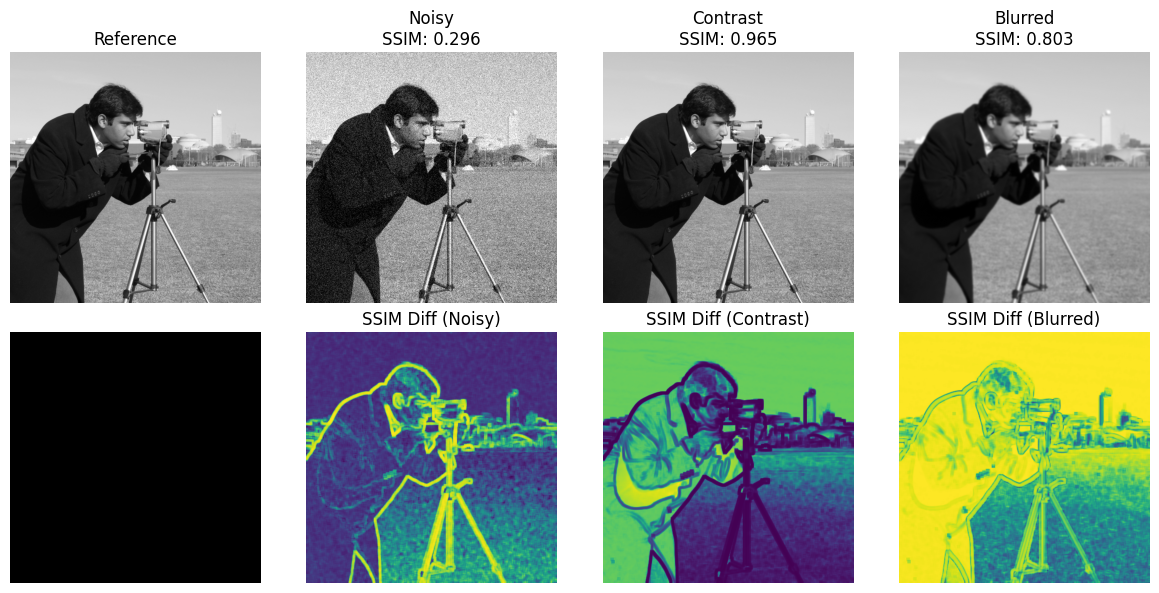

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi (grayscale)
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra terdistorsi
image_same = image_ref.copy()  # a) Citra sama
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)  # b) Dengan noise Gaussian
image_contrast = np.clip(image_ref * 0.8, 0, 1)  # c) Kontras lebih rendah
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # d) Blur

# 3. Hitung SSIM (Structural Similarity Index)
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan nilai SSIM
print(f"SSIM (Ref vs Same)     : {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy)    : {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast) : {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred)  : {ssim_blurred:.4f}")

# 5. Visualisasi citra dan peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris atas: citra asli dan hasil distorsi
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')

# Baris bawah: peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')  # Kosong (placeholder)
ax[4].set_title('')
ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Diff (Noisy)')
ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Diff (Contrast)')
ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Diff (Blurred)')

# Hilangkan axis
for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


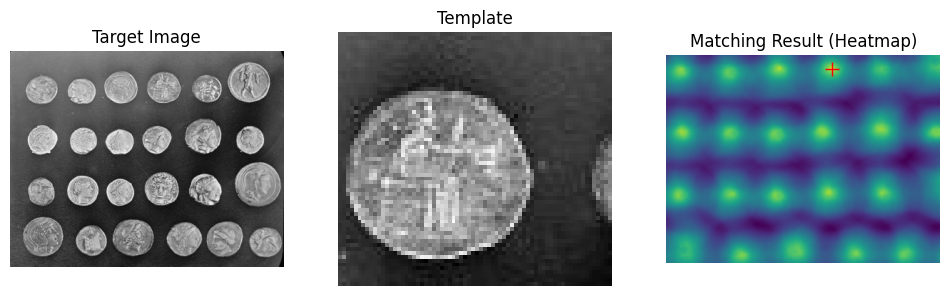

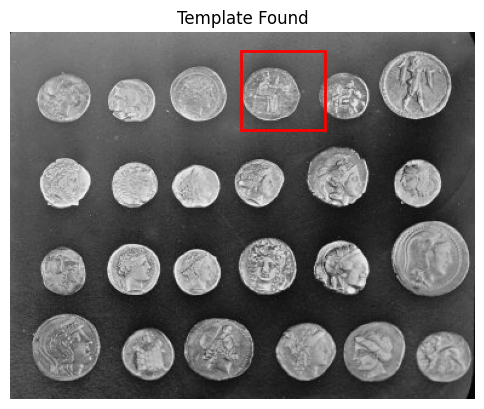

Template ditemukan di koordinat (x, y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target (koin) dan template (salah satu koin)
image = data.coins()
template = image[15:80, 190:260]  # Sesuaikan koordinat jika ingin ambil koin berbeda

# 2. Lakukan template matching menggunakan normalized cross-correlation
result = match_template(image, template)

# 3. Temukan lokasi dengan skor tertinggi (hasil terbaik)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Hasil koordinat (x, y) dari sudut kiri atas template

# 4. Visualisasi: tampilkan gambar target, template, dan hasil matching
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Gambar asli
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].plot(x, y, 'r+', markersize=10)  # Titik deteksi terbaik
ax[2].axis('off')

# 5. Tampilkan citra asli dengan kotak menunjukkan lokasi hasil matching
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')

# Tambahkan kotak persegi panjang di lokasi yang ditemukan
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', linewidth=2)
ax_main.add_patch(rect)

plt.show()

# 6. Cetak koordinat lokasi template ditemukan
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")


Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


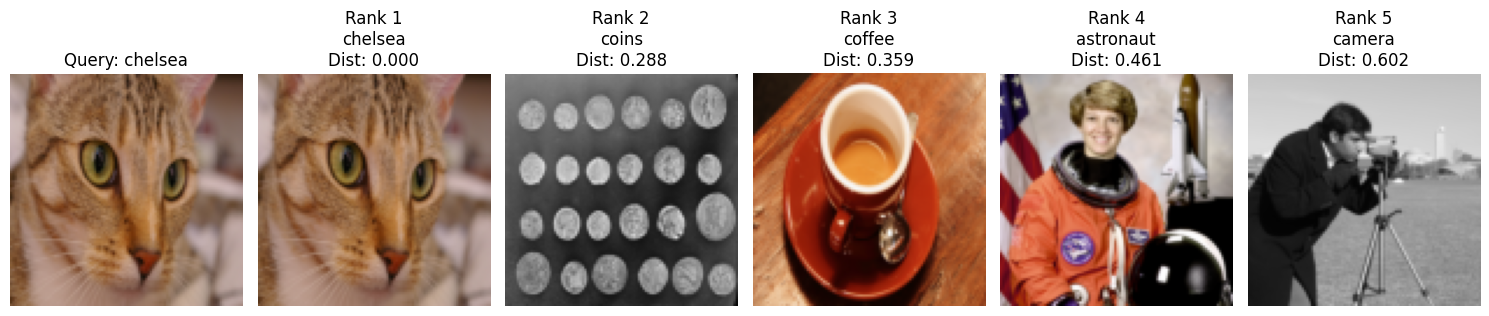

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    """Menghitung histogram RGB dan menormalisasinya."""
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined

# Daftar nama gambar dari skimage.data
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih salah satu gambar sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# Hitung jarak cosine antara query dan gambar lainnya
distances = []
for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# Urutkan hasil berdasarkan kemiripan (jarak terkecil)
sorted_indices = np.argsort(distances)

# Tampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


Memproses database citra dengan fitur rata-rata warna...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


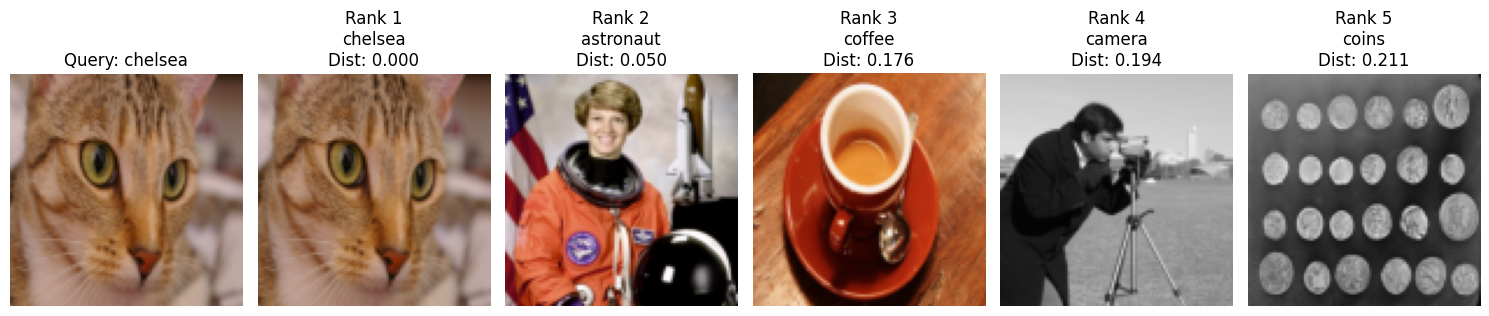

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_mean(image):
    """Menghitung rata-rata nilai R, G, B sebagai fitur vektor 3 dimensi."""
    if image.ndim == 2:
        image = color.gray2rgb(image)
    if image.dtype != float:
        image = img_as_float(image)
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# Daftar nama gambar dari skimage.data
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database citra dengan fitur rata-rata warna...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_features.append(calculate_rgb_mean(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih salah satu gambar sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

# Hitung jarak Euclidean antara query dan gambar lainnya
distances = []
for feat in database_features:
    dist = distance.euclidean(query_feature, feat)
    distances.append(dist)

# Urutkan hasil berdasarkan kemiripan (jarak terkecil)
sorted_indices = np.argsort(distances)

# Tampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


Template asli:


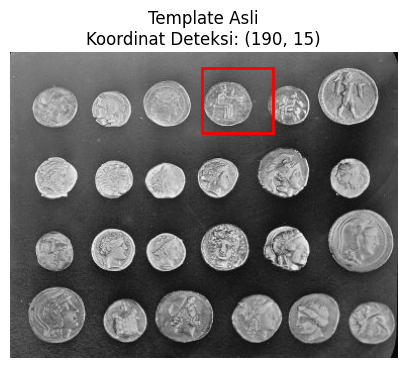

Template diputar 30 derajat:


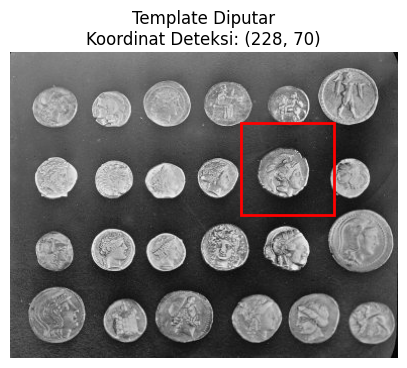

Template diperbesar 1.5x:


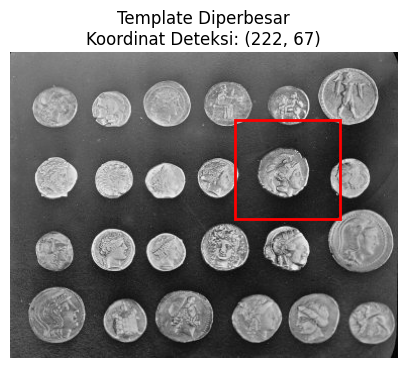

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# 1. Muat citra target
image = data.coins()

# 2. Ambil template asli dari citra
template = image[15:80, 190:260]  # Sesuaikan sesuai koin

# 3. Buat template yang dirotasi dan diskalakan
template_rotated = transform.rotate(template, angle=30, resize=True)  # rotasi 30 derajat
template_scaled = transform.rescale(template, scale=1.5, anti_aliasing=True)

# 4. Fungsi pencocokan dan visualisasi
def match_and_show(image, template, title):
    result = match_template(image, template)
    ij = np.unravel_index(np.argmax(result), result.shape)
    x, y = ij[::-1]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image, cmap='gray')
    ax.set_title(f'{title}\nKoordinat Deteksi: ({x}, {y})')
    ax.axis('off')

    h, w = template.shape
    rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', linewidth=2)
    ax.add_patch(rect)
    plt.show()

# 5. Tes dengan template asli, diputar, dan diskalakan
print("Template asli:")
match_and_show(image, template, "Template Asli")

print("Template diputar 30 derajat:")
match_and_show(image, template_rotated, "Template Diputar")

print("Template diperbesar 1.5x:")
match_and_show(image, template_scaled, "Template Diperbesar")
